# Q1. Supervised Learning

In [37]:
import pandas as pd

## 1.Data Loading and Inspection

In [38]:
# load dataset 
df= pd.read_csv("C:/Users/Shivangi/OneDrive/Desktop/assignment 4 A and B/q1_heart_disease.csv")

# Basic Insepection
print("Shape:",df.shape)
print("\nData Types: \n", df.dtypes)
print("\nMissing Values: \n", df.isnull().sum())

df.head()


Shape: (800, 12)

Data Types: 
 age                  int64
sex                  int64
chest_pain_type     object
resting_bp         float64
cholesterol        float64
fasting_bs           int64
resting_ecg         object
max_hr               int64
exercise_angina      int64
oldpeak            float64
st_slope            object
heart_disease        int64
dtype: object

Missing Values: 
 age                 0
sex                 0
chest_pain_type     0
resting_bp         24
cholesterol        32
fasting_bs          0
resting_ecg         0
max_hr              0
exercise_angina     0
oldpeak             0
st_slope            0
heart_disease       0
dtype: int64


,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_bs,resting_ecg,max_hr,exercise_angina,oldpeak,st_slope,heart_disease
0,68,0,atypical_angina,142.0,399.0,0,left_ventricular_hypertrophy,169,0,0.4,up,1
1,58,1,non_anginal,163.0,310.0,1,st_t_wave_abnormality,121,1,1.1,up,1
2,44,1,non_anginal,128.0,175.0,0,normal,183,1,0.2,up,0
3,72,1,asymptomatic,114.0,177.0,0,st_t_wave_abnormality,150,0,1.0,up,1
4,37,1,non_anginal,149.0,271.0,0,normal,136,0,0.4,flat,0


Dataset contains 800 rows and 12 columns
Some missing values observed in resting_bp and cholestrol column

## 2. Exploratory Data Analysis

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

<function matplotlib.pyplot.show(close=None, block=None)>

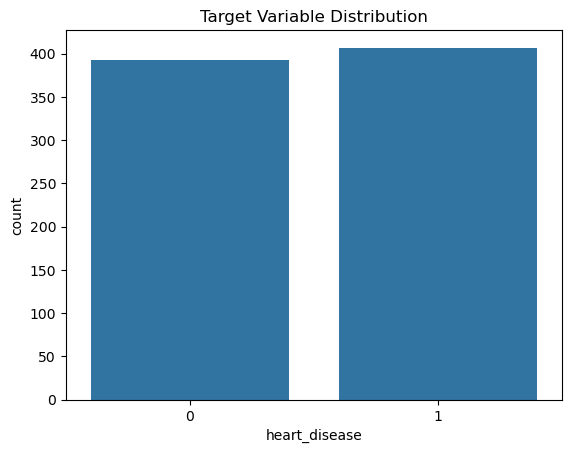

In [40]:
# Target Distribution
sns.countplot(x='heart_disease', data=df)
plt.title("Target Variable Distribution")
plt. show

The target variable is almost perfetly balanced with 407 patients having heart disease and 393 not having it , indicating that dataset does not suffer from class imbalance. This is beneficial for model training as it reduces bias towards one class.

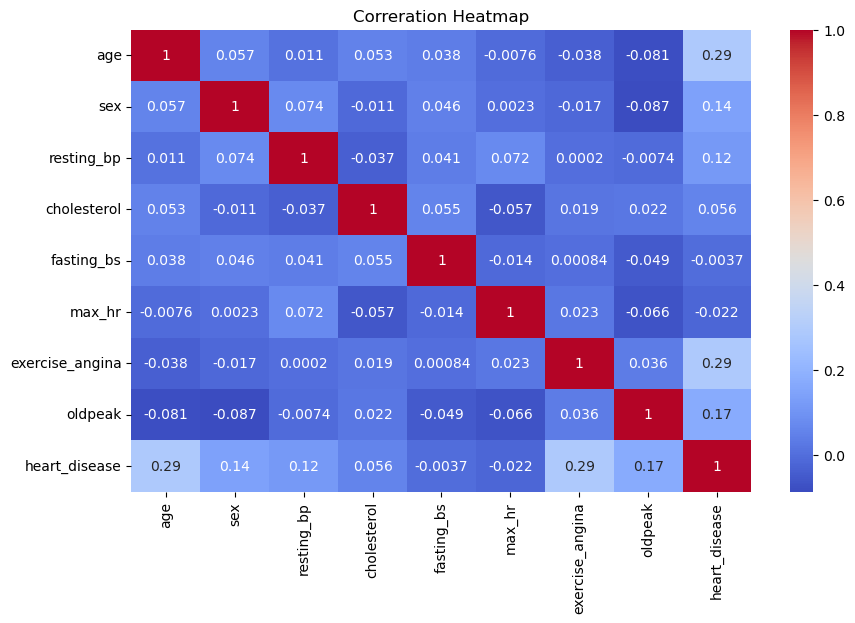

In [41]:
#Correlation Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.select_dtypes(include=['number']).corr(), annot=True ,cmap= 'coolwarm')
plt.title("Correration Heatmap")
plt.show()

From the corretaion heat map Age (0.29) and Exercise angina (0.29) show the highest positive correlation with heart disease, suggesting that older patients andd those experiencing exercise induced agina are more likely to have heart disease.

the feature olpeak also shows moderate positive correlaion, indicating that higher ST depression lavels are associated with increased likelihood of heart disease.

max_hr has the slight negative relationship, which may suggest that patients with heart disease tend to achieve lower maximum heart rates during exercise

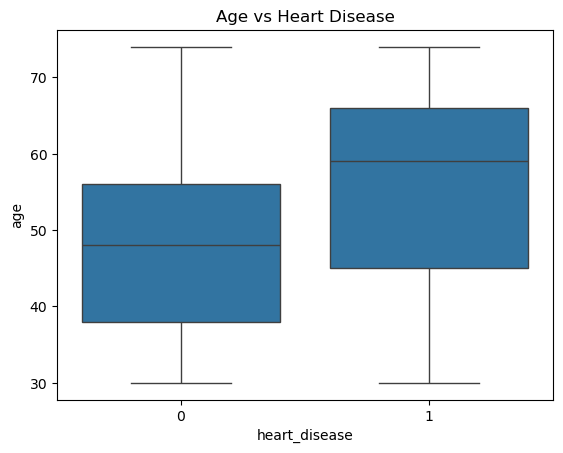

In [42]:
# Age Distribution vs Target
sns.boxplot(x= 'heart_disease', y='age', data=df)
plt.title("Age vs Heart Disease")
plt.show()

From the boxplot analysis, patients with heart disease are slightly older on an average, indicating age as an important risk factor

 ## 3.Data Preprocessing

In [43]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [44]:
# Handle missing Value
df.fillna(df.median(numeric_only= True),inplace=True)

In [45]:
# one-hot encoding
df= pd.get_dummies(df,drop_first= True)

#Split Features and target
X = df.drop('heart_disease', axis=1)
y = df['heart_disease']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Scaling
scaler= StandardScaler()
X_train= scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Used median imputation because it is robust to outliers

One-hot encoding applied to convert categorical variables

StandardScaler used to normalize feature ranges

Stratified split ensures class balance

## 4. Module Training

In [46]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

In [47]:
# Models
dt= DecisionTreeClassifier(random_state=42)
rf= RandomForestClassifier(random_state=42)
gb=GradientBoostingClassifier(random_state=42)

# Train
dt.fit(X_train, y_train)
rf.fit(X_train, y_train)
gb.fit(X_train, y_train)

GradientBoostingClassifier(random_state=42)

## 5. Model Evaluation

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

models = {
    "Decision Tree": dt,
    "Random Forest": rf,
    "Gradient Boosting": gb
}

for name, model in models.items():
    print(f"\n{name}")
    y_pred= model.predict(X_test)
    
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))


Random Forest performed best due to higher F1-score

It balances precision and recall better than other models

Decision Tree may overfit, while Gradient Boosting performs well but slightly lower


## 6. Hyperparameter Tuning

In [36]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring='f1'
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

# Evaluate tuned model
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

print("Tuned Model Report:\n", classification_report(y_test, y_pred))

Best Parameters: {'max_depth': None, 'n_estimators': 200}
Tuned Model Report:
               precision    recall  f1-score   support

           0       0.78      0.75      0.76        79
           1       0.76      0.79      0.78        81

    accuracy                           0.77       160
   macro avg       0.77      0.77      0.77       160
weighted avg       0.77      0.77      0.77       160



The best parameters obtained from GridSearchCV are:

n_estimators = 200

max_depth = None

The tuned Random Forest model achieved an overall accuracy of 77%, with an F1-score of 0.78 for class 1 (heart disease) and 0.76 for class 0 (no disease).

The model demonstrates a balanced performance across both classes, as precision and recall values are relatively close. This indicates that the model is not biased toward predicting only one class.

Compared to the baseline model, the tuned model shows slight improvement in F1-score, suggesting better balance between precision and recall after optimization.

Overall, hyperparameter tuning helped improve model generalization and ensured more reliable predictions on unseen data.